**Re-executed 2026-07-25 under flopscope 0.9.1 (PR150 merged) + whestbench 0.13.0.** No path fixes were needed: the captures load from the preserved algo43 bytes (`submissions/algo43-coldslice/estimator.py`, submission 318803) via the checked-in caches `.coldslice_viz_cache.npz` / `.coldslice_vals_cache.npz`. Figure titles now state the net sample (aicrowd/arc-whestbench-public-2026, v1-phase1, mini split).

# Cold-column slicing: the zero blocks it carves (submission 318803)

For three example layers on three public MLPs of increasing difficulty (ranked by
the estimator's final-layer MSE on the 10-net benchmark: net 10 easy 1.30e-7,
net 70 medium 2.58e-7, net 0 hard 9.20e-7), this notebook captures the **actual
continuation-block sample matrix** the shipped estimator sees (51,200 rows ×
active columns), applies the same cold-first column order and support-first row
order the algorithm uses, and draws the fired/zero mask. The bottom-left
rectangle — non-support rows × cold columns — is **all zero by construction**
and is exactly the shape the matmul never touches.

In [1]:
import sys, importlib.util
from pathlib import Path
import numpy as np

REPO = Path("/Users/natashastewart/whest-kprop-experiments")
sys.path.insert(0, str(REPO))
import flopscope as flops
import whestbench as wb
from whestbench import SetupContext

TARGET_LAYERS = [5, 15, 27]
NETS = [(10, "easy", "1.30e-7"), (70, "medium", "2.58e-7"), (0, "hard", "9.20e-7")]
CACHE = REPO / ".coldslice_viz_cache.npz"

def _capture_net(est_path, net_id):
    spec = importlib.util.spec_from_file_location("est43v", est_path)
    est = importlib.util.module_from_spec(spec); spec.loader.exec_module(est)
    plan_holder = {}
    orig_plan = est._plan_cold_slices
    def plan_spy(structure, n_pilot):
        plan = orig_plan(structure, n_pilot)
        plan_holder.update(plan)
        return plan
    est._plan_cold_slices = plan_spy
    caps, call_no = {}, [0]
    orig_cold = est._cold_slice_relu_matmul
    def cold_spy(x, w_active, kc):
        layer = sorted(plan_holder)[call_no[0]]; call_no[0] += 1
        if layer in TARGET_LAYERS:
            caps[layer] = (np.asarray(x) > 0, kc)
        return orig_cold(x, w_active, kc)
    est._cold_slice_relu_matmul = cold_spy
    E = est.Estimator()
    B = 272_000_000_000
    E.setup(SetupContext(seed=0, width=256, depth=32, flop_budget=B,
                         api_version="v1", submission_dir=str(REPO)))
    with flops.BudgetContext(flop_budget=B):
        E.predict(wb.mlp_at(ds, net_id), B)
    return caps

if CACHE.exists():
    z = np.load(CACHE, allow_pickle=True)
    captures = {(ni, li): (z[f"mask_{ni}_{li}"], int(z[f"kc_{ni}_{li}"]))
                for ni, _, _ in NETS for li in TARGET_LAYERS}
else:
    flops.configure(symmetry_warnings=False)
    ds = wb.load_dataset("aicrowd/arc-whestbench-public-2026", revision="v1-phase1", split="mini")
    captures = {}
    for ni, _, _ in NETS:
        caps = _capture_net(str(REPO / "submissions/algo43-coldslice/estimator.py"), ni)
        for li, v in caps.items():
            captures[(ni, li)] = v
    np.savez_compressed(CACHE,
                        **{f"mask_{ni}_{li}": m for (ni, li), (m, _) in captures.items()},
                        **{f"kc_{ni}_{li}": kc for (ni, li), (_, kc) in captures.items()})

for ni, tag, _ in NETS:
    for li in TARGET_LAYERS:
        mask, kc = captures[(ni, li)]
        print(f"net {ni:2d} ({tag:6s}) layer {li:2d}: {mask.shape[0]} x {mask.shape[1]}, "
              f"k={kc}, density={mask.mean():.2f}")

/Users/natashastewart/whest-kprop-experiments/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


net 10 (easy  ) layer  5: 51200 x 253, k=25, density=0.50
net 10 (easy  ) layer 15: 51200 x 211, k=29, density=0.58
net 10 (easy  ) layer 27: 51200 x 192, k=25, density=0.62
net 70 (medium) layer  5: 51200 x 252, k=16, density=0.50
net 70 (medium) layer 15: 51200 x 208, k=30, density=0.61
net 70 (medium) layer 27: 51200 x 170, k=23, density=0.68
net  0 (hard  ) layer  5: 51200 x 251, k=26, density=0.49
net  0 (hard  ) layer 15: 51200 x 212, k=41, density=0.57
net  0 (hard  ) layer 27: 51200 x 192, k=28, density=0.69


Columns arrive **already cold-first** (the plan permuted the producing layer's
active list, so the weight slice emitted them in fire-ascending order). The row
partition below reproduces the estimator's scatter: rows with any fired entry in
the cold block first, the rest after.

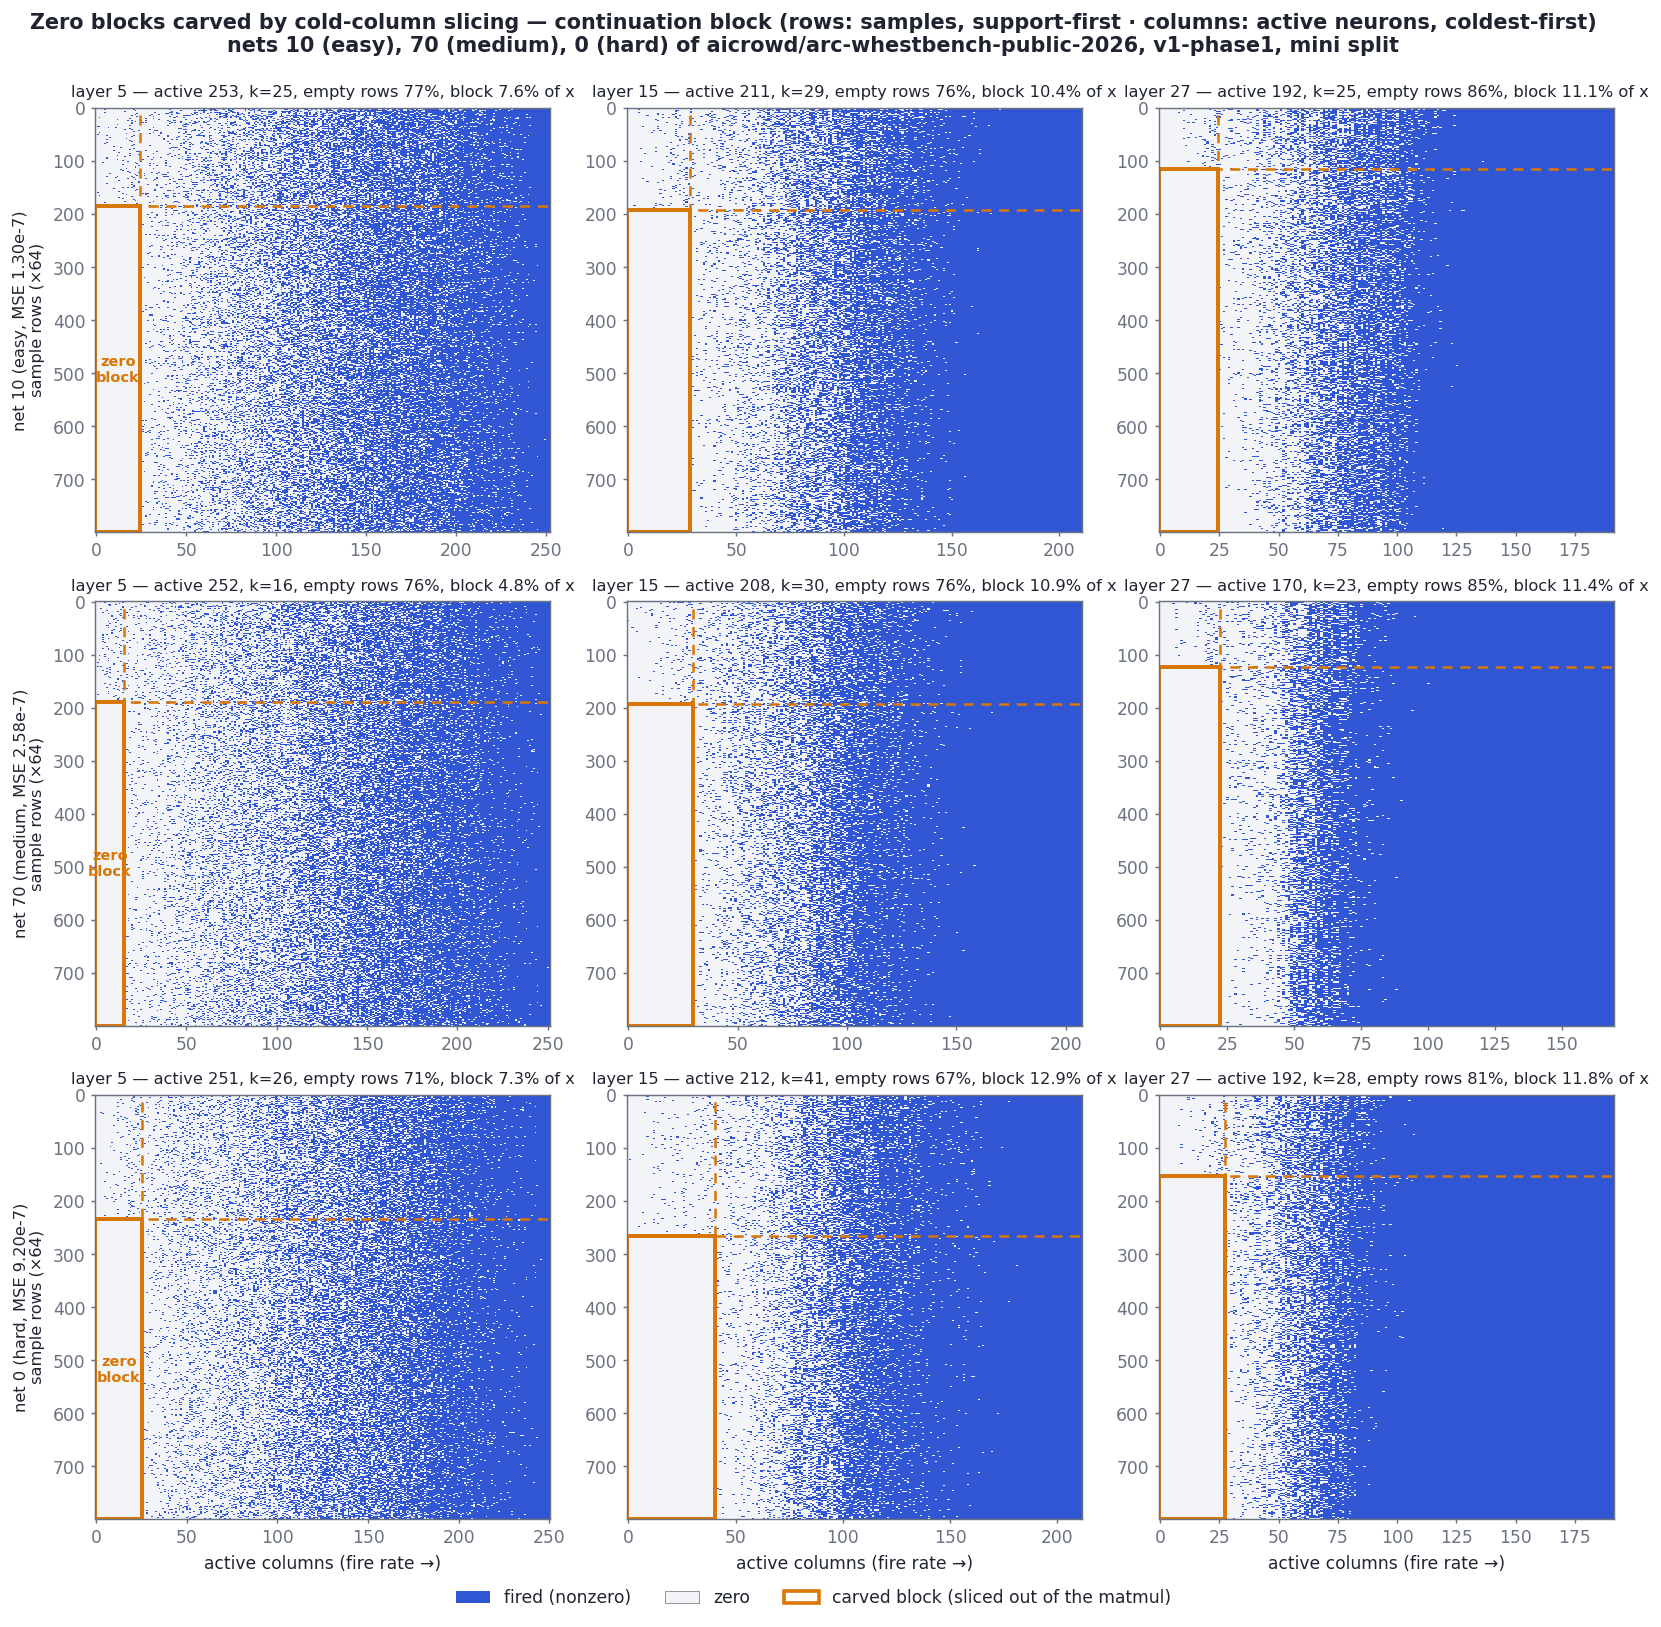

In [2]:
import matplotlib.pyplot as plt

INK = "#1f2430"; MUT = "#6b7280"
FIRED = "#3056d3"      # single categorical hue: "fired" cells
ZERO = "#f2f4f7"       # near-surface: zero cells
RECT = "#d97706"       # the carved block outline
plt.rcParams.update({"figure.dpi": 130, "font.size": 9.5, "text.color": INK,
                     "axes.edgecolor": MUT, "axes.labelcolor": INK,
                     "xtick.color": MUT, "ytick.color": MUT})

STRIDE = 64  # display every 64th row (51,200 -> 800), boundary preserved by sorting first
fig, axgrid = plt.subplots(3, 3, figsize=(12.6, 12.2))
fig.suptitle("Zero blocks carved by cold-column slicing — continuation block "
             "(rows: samples, support-first · columns: active neurons, coldest-first)\n"
             "nets 10 (easy), 70 (medium), 0 (hard) of aicrowd/arc-whestbench-public-2026, v1-phase1, mini split",
             fontsize=11.5, fontweight="bold", y=0.995)

panels = [(axgrid[r][c], NETS[r], TARGET_LAYERS[c]) for r in range(3) for c in range(3)]
for ax, (ni, tag, msestr), li in panels:
    mask, kc = captures[(ni, li)]
    n, acts = mask.shape
    has = mask[:, :kc].any(axis=1)
    n_sup = int(has.sum())
    order = np.argsort(~has, kind="stable")     # support rows first, like the scatter
    disp = mask[order][::STRIDE]
    dn = disp.shape[0]
    ax.imshow(np.where(disp, 1, 0), aspect="auto", interpolation="nearest",
              cmap=plt.matplotlib.colors.ListedColormap([ZERO, FIRED]))
    bnd = n_sup / STRIDE
    ax.axvline(kc - 0.5, color=RECT, lw=1.4, ls=(0, (4, 3)))
    ax.axhline(bnd - 0.5, color=RECT, lw=1.4, ls=(0, (4, 3)))
    from matplotlib.patches import Rectangle
    ax.add_patch(Rectangle((-0.5, bnd - 0.5), kc, dn - bnd, fill=False,
                           edgecolor=RECT, lw=2.2))
    rect_share = (n - n_sup) * kc / (n * acts)
    ax.set_title(f"layer {li} — active {acts}, k={kc}, "
                 f"empty rows {100 * (1 - n_sup / n):.0f}%, block {100 * rect_share:.1f}% of x",
                 fontsize=9)
    if li == TARGET_LAYERS[-1] and tag == NETS[-1][1]:
        pass
    if tag == NETS[2][1] or ax in axgrid[2]:
        ax.set_xlabel("active columns (fire rate →)")
    if li == TARGET_LAYERS[0]:
        ax.set_ylabel(f"net {ni} ({tag}, MSE {msestr})\nsample rows (×{STRIDE})", fontsize=9)
    if li == TARGET_LAYERS[0]:
        ax.text(kc / 2 - 0.5, (bnd + dn) / 2, "zero\nblock",
                ha="center", va="center", fontsize=8, color=RECT, fontweight="bold")
    ax.tick_params(length=2)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(fc=FIRED, label="fired (nonzero)"),
                    Patch(fc=ZERO, ec=MUT, lw=0.4, label="zero"),
                    Patch(fc="none", ec=RECT, lw=2, label="carved block (sliced out of the matmul)")],
           loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
fig.savefig("/Users/natashastewart/whest-kprop-experiments/coldslice_blocks.png",
            bbox_inches="tight", facecolor="white")
plt.show()

**Reading the figure.** Rows of the grid are MLPs by difficulty (easy net 10,
medium net 70, hard net 0 — ranked by the estimator's final-layer MSE); columns
are layers 5/15/27. Everything left of the dashed vertical line is the cold
set (the k lowest-fire columns); everything below the dashed horizontal line is
the rows whose cold entries are all zero. Their intersection — the outlined
rectangle — is white by construction: it is the region the estimator proves empty
with a k-column test and then routes around with free slices. The scattered blue
specks *above* the line in the cold columns are the rare cold firings — they are
kept exactly, via the small correction matmul over just those rows. The dense blue
mass right of the line is the hot block, which all rows traverse through the
2-level Strassen path. Note the zeros scattered through the hot region: those are
the ~35% of zeros cold-slicing deliberately does NOT chase — they form no cheap
contiguous shape, and the repriced gather ops make per-row packing of them a loss.

## How the recursion works (Algorithm 44 / submission 318873)

Same matrix (hard net 0, layer 15 — the widest cold set), two ways of ordering the
rows. **Left:** the single-level carve — rows split only by *any cold support*, one
zero rectangle. **Right:** the recursion — the cold set is split into an ultra-cold
slab [0, k₂) and a warm-cold slab [k₂, k), and rows are ordered by their support
**pattern**: {both slabs, ultra-only, warm-only, neither}. One scatter makes every
group contiguous, and each group's matmul covers only the slabs it needs — so the
carved region grows from one rectangle to **three**: ultra-only rows skip the warm
slab, warm-only rows skip the ultra slab, and pattern-none rows skip both.

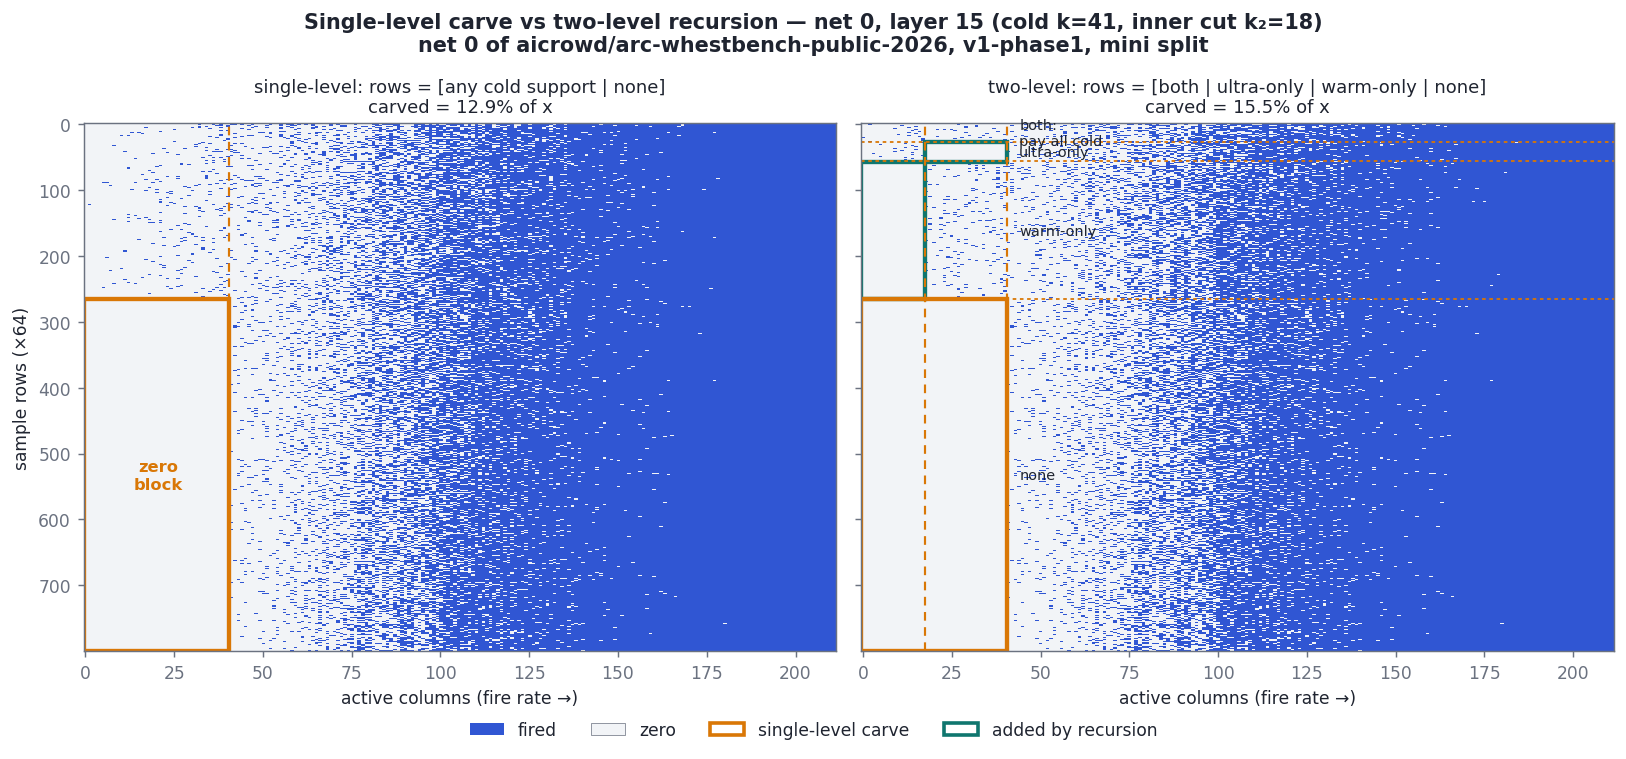

In [3]:
from matplotlib.patches import Rectangle, Patch

NI, LI = 0, 15
mask, kc = captures[(NI, LI)]
n, acts = mask.shape
fire = mask.mean(0)
# columns already coldest-first in the capture; inner cut at the 1% fire rate
k2 = int(np.clip((fire[:kc] < 0.01).sum(), 4, kc - 4))
hu = mask[:, :k2].any(1)
hw = mask[:, k2:kc].any(1)
RECUR = "#0f766e"   # recursion-added carve accent

fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.6), sharey=True)
fig.suptitle(f"Single-level carve vs two-level recursion — net {NI}, layer {LI} "
             f"(cold k={kc}, inner cut k₂={k2})\n"
             f"net {NI} of aicrowd/arc-whestbench-public-2026, v1-phase1, mini split",
             fontsize=11.5, fontweight="bold")

# ---- left: single level (algo43 / 318803) ----
has = hu | hw
n_sup = int(has.sum())
order = np.argsort(~has, kind="stable")
disp = mask[order][::STRIDE]; dn = disp.shape[0]
ax = axes[0]
ax.imshow(np.where(disp, 1, 0), aspect="auto", interpolation="nearest",
          cmap=plt.matplotlib.colors.ListedColormap([ZERO, FIRED]))
b = n_sup / STRIDE
ax.axvline(kc - 0.5, color=RECT, lw=1.2, ls=(0, (4, 3)))
ax.add_patch(Rectangle((-0.5, b), kc, dn - b, fill=False, edgecolor=RECT, lw=2.4))
share = (n - n_sup) * kc / (n * acts)
ax.set_title(f"single-level: rows = [any cold support | none]\ncarved = {100*share:.1f}% of x", fontsize=10)
ax.set_ylabel("sample rows (×64)")
ax.set_xlabel("active columns (fire rate →)")
ax.text(kc / 2, (b + dn) / 2, "zero\nblock", ha="center", va="center",
        color=RECT, fontsize=9, fontweight="bold")

# ---- right: two-level pattern ordering (algo44 / 318873) ----
gid = np.where(hu & hw, 0, np.where(hu & ~hw, 1, np.where(~hu & hw, 2, 3)))
order = np.argsort(gid, kind="stable")
disp = mask[order][::STRIDE]; dn = disp.shape[0]
nb_, nu_, nw_ = int((gid == 0).sum()), int((gid == 1).sum()), int((gid == 2).sum())
b1, b2, b3 = nb_ / STRIDE, (nb_ + nu_) / STRIDE, (nb_ + nu_ + nw_) / STRIDE
ax = axes[1]
ax.imshow(np.where(disp, 1, 0), aspect="auto", interpolation="nearest",
          cmap=plt.matplotlib.colors.ListedColormap([ZERO, FIRED]))
ax.axvline(k2 - 0.5, color=RECT, lw=1.2, ls=(0, (4, 3)))
ax.axvline(kc - 0.5, color=RECT, lw=1.2, ls=(0, (4, 3)))
for y in (b1, b2, b3):
    ax.axhline(y - 0.5, color=RECT, lw=1.0, ls=(0, (2, 2)))
# carved rectangles: ultra-only rows skip warm slab; warm-only skip ultra; none skip all
ax.add_patch(Rectangle((k2 - 0.5, b1), kc - k2, b2 - b1, fill=False, edgecolor=RECUR, lw=2.4))
ax.add_patch(Rectangle((-0.5, b2), k2, b3 - b2, fill=False, edgecolor=RECUR, lw=2.4))
ax.add_patch(Rectangle((-0.5, b3), kc, dn - b3, fill=False, edgecolor=RECT, lw=2.4))
carved = (nu_ * (kc - k2) + nw_ * k2 + (n - nb_ - nu_ - nw_) * kc) / (n * acts)
ax.set_title("two-level: rows = [both | ultra-only | warm-only | none]\n"
             f"carved = {100*carved:.1f}% of x", fontsize=10)
ax.set_xlabel("active columns (fire rate →)")
for y, lab in ((b1 / 2, "both:\npay all cold"), ((b1 + b2) / 2, "ultra-only"),
               ((b2 + b3) / 2, "warm-only"), ((b3 + dn) / 2, "none")):
    ax.text(kc + 3, y, lab, va="center", fontsize=8, color=INK)

fig.legend(handles=[Patch(fc=FIRED, label="fired"), Patch(fc=ZERO, ec=MUT, lw=0.4, label="zero"),
                    Patch(fc="none", ec=RECT, lw=2, label="single-level carve"),
                    Patch(fc="none", ec=RECUR, lw=2, label="added by recursion")],
           loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.04))
plt.tight_layout()
fig.savefig("/Users/natashastewart/whest-kprop-experiments/coldslice_recursion.png",
            bbox_inches="tight", facecolor="white")
plt.show()

**Reading it:** the right panel's row order is what one `put_along_axis` scatter
produces in the shipped Algorithm 44. Each group's needed columns are a contiguous
slab, so its correction matmul reads a free slice and its result adds onto a
contiguous slice of the hot output — no scatter-adds, no order restoration. The
teal rectangles are the area recursion reclaims on top of the single-level carve:
ultra-only rows' warm slab and warm-only rows' ultra slab, both all-zero by
definition of the groups. The "both" group (top) still pays the full cold width —
it is small precisely because firing in *two* rare column sets is rare.

## Low-rank structure of the hot/on block (layer 27, hard net 0)

The dense right side of the earlier panels — the hot block — is nearly full in
*support* but collapses in *spectrum*: deep-layer activations are strongly
cross-correlated, so a few directions carry almost all of the second-moment
energy. Below: the actual continuation-block values, their rank-r
reconstruction, and what is left over.

In [4]:
VCACHE = REPO / ".coldslice_vals_cache.npz"
VLAYER, VNET = 27, 0
if VCACHE.exists():
    _v = np.load(VCACHE)
    XH, KC27 = _v["xh"], int(_v["kc"])
else:
    spec = importlib.util.spec_from_file_location(
        "est43x", str(REPO / "submissions/algo43-coldslice/estimator.py"))
    estx = importlib.util.module_from_spec(spec); spec.loader.exec_module(estx)
    ph, vals, cn = {}, {}, [0]
    op = estx._plan_cold_slices
    def ps(s, n):
        p = op(s, n); ph.update(p); return p
    estx._plan_cold_slices = ps
    oc = estx._cold_slice_relu_matmul
    def cs(x, w, kc):
        ly = sorted(ph)[cn[0]]; cn[0] += 1
        if ly == VLAYER:
            vals["x"] = np.asarray(x, np.float64); vals["kc"] = kc
        return oc(x, w, kc)
    estx._cold_slice_relu_matmul = cs
    if "ds" not in dir():
        ds = wb.load_dataset("aicrowd/arc-whestbench-public-2026",
                             revision="v1-phase1", split="mini")
    Ex = estx.Estimator()
    Bx = 272_000_000_000
    Ex.setup(SetupContext(seed=0, width=256, depth=32, flop_budget=Bx,
                          api_version="v1", submission_dir=str(REPO)))
    with flops.BudgetContext(flop_budget=Bx):
        Ex.predict(wb.mlp_at(ds, VNET), Bx)
    XH = vals["x"][:, vals["kc"]:]     # the hot block
    KC27 = vals["kc"]
    np.savez_compressed(VCACHE, xh=XH.astype(np.float32), kc=KC27)

XH = XH.astype(np.float64)
n, p = XH.shape
U, S, Vt = np.linalg.svd(XH, full_matrices=False)
energy = np.cumsum(S**2) / np.sum(S**2)
print(f"hot block: {n} x {p}; energy at r=8: {100*energy[7]:.2f}%, "
      f"r=48: {100*energy[47]:.3f}%, break-even r* ~ {p*p/(2*p):.0f}")

hot block: 51200 x 164; energy at r=8: 99.17%, r=48: 99.901%, break-even r* ~ 82


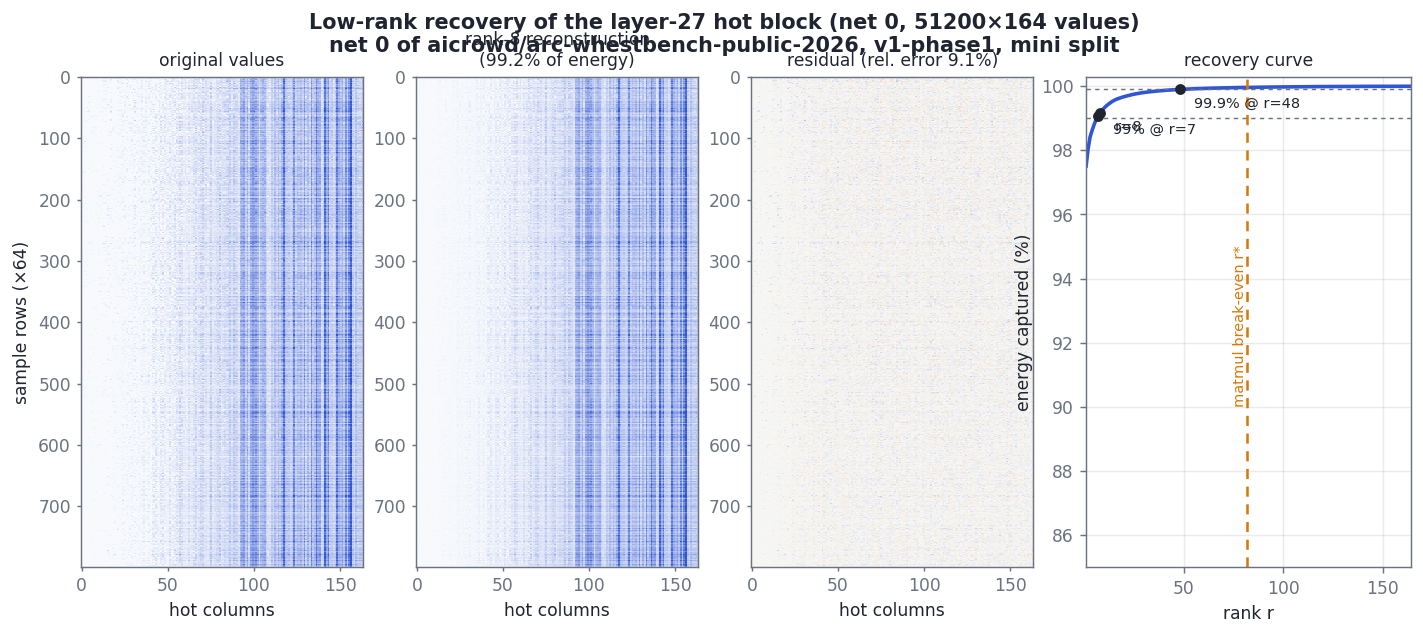

In [5]:
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

def rank_r(r):
    return (U[:, :r] * S[:r]) @ Vt[:r]

R_SHOW = 8
XR = rank_r(R_SHOW)
RES = XH - XR
rel = np.linalg.norm(RES) / np.linalg.norm(XH)

rows = slice(0, n, 64)              # 800 display rows
vmax = np.quantile(XH, 0.995)
seq = LinearSegmentedColormap.from_list("seq", ["#f7f9fc", "#3056d3"])
div = LinearSegmentedColormap.from_list("div", ["#d97706", "#f7f7f5", "#3056d3"])

fig = plt.figure(figsize=(13.2, 4.9))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 1.15], wspace=0.18)
fig.suptitle(f"Low-rank recovery of the layer-{VLAYER} hot block (net {VNET}, {n}×{p} values)\n"
f"net {VNET} of aicrowd/arc-whestbench-public-2026, v1-phase1, mini split",
             fontsize=11.5, fontweight="bold")

for i, (mat, title, cmap, norm) in enumerate([
        (XH[rows], "original values", seq, None),
        (XR[rows], f"rank-{R_SHOW} reconstruction\n({100*energy[R_SHOW-1]:.1f}% of energy)", seq, None),
        (RES[rows], f"residual (rel. error {100*rel:.1f}%)", div,
         TwoSlopeNorm(vcenter=0.0, vmin=-vmax/2, vmax=vmax/2))]):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(np.clip(mat, -vmax, vmax) if i == 2 else np.clip(mat, 0, vmax),
              aspect="auto", interpolation="nearest", cmap=cmap, norm=norm,
              vmin=None if norm else 0, vmax=None if norm else vmax)
    ax.set_title(title, fontsize=9.5)
    ax.set_xlabel("hot columns")
    if i == 0:
        ax.set_ylabel("sample rows (×64)")
    ax.tick_params(length=2)

ax = fig.add_subplot(gs[0, 3])
rr = np.arange(1, p + 1)
ax.plot(rr, 100 * energy, color="#3056d3", lw=2)
ax.axhline(99.0, color=MUT, lw=0.8, ls=(0, (3, 3)))
ax.axhline(99.9, color=MUT, lw=0.8, ls=(0, (3, 3)))
ax.axvline(p * p / (2 * p), color="#d97706", lw=1.4, ls=(0, (4, 3)))
r99 = int(np.searchsorted(energy, 0.99) + 1)
r999 = int(np.searchsorted(energy, 0.999) + 1)
for r, lab in ((R_SHOW, f"r={R_SHOW}"), (r99, f"99% @ r={r99}"), (r999, f"99.9% @ r={r999}")):
    ax.plot([r], [100 * energy[r - 1]], "o", ms=5, color="#1f2430")
    ax.annotate(lab, (r, 100 * energy[r - 1]), textcoords="offset points",
                xytext=(8, -10), fontsize=8, color=INK)
ax.annotate("matmul break-even r*", (p / 2, 90), rotation=90, fontsize=8,
            color="#d97706", ha="right", va="bottom")
ax.set_xlim(1, p); ax.set_ylim(85, 100.3)
ax.set_xlabel("rank r"); ax.set_ylabel("energy captured (%)")
ax.set_title("recovery curve", fontsize=9.5)
ax.grid(alpha=0.25)

fig.savefig(str(REPO / "coldslice_lowrank.png"), bbox_inches="tight", facecolor="white")
plt.show()

**Reading it.** The original and the rank-8 reconstruction are nearly
indistinguishable by eye — eight directions out of ~164 carry ~99% of the
second-moment energy, and the residual panel is close to blank at the shared
color scale (the diverging map shows what little structure remains, scattered
and sign-balanced). The curve on the right shows why this is tantalizing:
99%/99.9% recovery happens far to the left of the matmul break-even rank r*.
The caveat that keeps this from being a free win: unlike the cold-slice
rectangles, truncation is *lossy* — the residual is a systematic perturbation
that ReLU converts into bias on the scored mean, so the next required
measurement is the truncation-bias curve on the final row, not more FLOP math.